# Trabajo Práctico 2 - Visión por Computadora

Integrantes:
- Matías Guillermo Alfaro
- Rodrigo Hernández
- Gonzalo Cuervo
- Nicolas Alberto Tonnelier
- Marina Andrea Racciatti

# Objetivo:
Implementar un detector de máximo enfoque sobre un video aplicando técnicas de análisis espectral similar al que utilizan las  cámaras digitales modernas. El video a procesar será: “focus_video.mov”.

## 1.
Se debe implementar un algoritmo que dada una imagen, o región, calcule la métrica propuesta en el paper "Image Sharpness Measure for Blurred Images in Frequency Domain“ y realizar dos experimentos:

### 1.1
Medición sobre todo el frame.

### 2.1
Medición sobre una ROI ubicada en el centro del frame. Area de la ROI = 5 o 10% del area total del frame.

Para cada experimento se debe presentar una curva o varias curvas que muestren la evolución de la métrica frame a frame donde se vea claramente cuando el algoritmo detecto la región de máximo enfoque.

El algoritmo de detección a implementar debe detectar y devolver los puntos de máximo enfoque de manera automática.

Puntos extra: Aplicar unsharp masking para expandir la zona de enfoque y devolver.

Matriz de enfoque superpuesta a uno de los frames del video:

![Matriz de enfoque en un frame 1](recursos/matriz-de-enfoque-en-un-frame-1.png)

![Matriz de enfoque en un frame 2](recursos/matriz-de-enfoque-en-un-frame-2.png)

*Notas de la clase a tener en cuenta:*
- *En el TP solo tenemos que usar un cuadradito verde. No se permite buscar el maximo y definirlo como el punto.*
- *En la sección de puntos extra no se permite aplicar unsharp masking a todo, de debe aplicar en la región frontera y deberíamos ver que se ensanche.*

In [1]:
# Ejercicio 1: Algoritmo Image Sharpness Measure for Blurred Images in Frequency Domain

import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

# Input: Image I of size M×N.
# Output: Image Quality measure (FM) where FM stands for Frequency Domain Image Blur Measure
def image_sharpness_measure(img):
  # The measure operates on a single-channel image, so convert color frames to grayscale first.
  if img.ndim == 3:
    img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

  m_rows, n_cols = img.shape

  # Step 1: Compute F which is the Fourier Transform representation of image I
  f = np.fft.fft2(img)

  # Step 2: Find Fc which is obtained by shifting the origin of F to centre.
  fc = np.fft.fftshift(f)

  # Step 3: Calculate AF = abs (Fc) where AF is the absolute value of the centered Fourier transform of image I. 
  af = np.absolute(fc)

  # Step 4: Calculate M = max (AF) where M is the maximum value of the frequency component in F. 
  m = af.max()

  # Step 5: Calculate TH = the total number of pixels in F whose pixel value > thres, where thres = M/1000.
  thres = m / 1000
  th = np.count_nonzero(af > thres)

  # Step 6: Calculate Image Quality measure (FM) from equation: th/(M*N), where M*N is image dimensions
  fm = th / (m_rows * n_cols)

  return fm

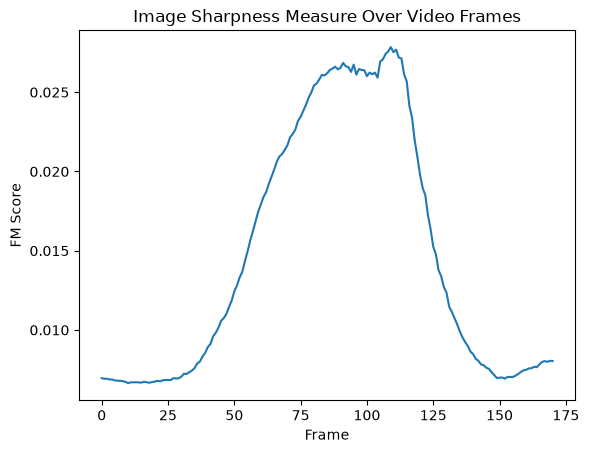

In [ ]:
# Ejercicio 1.1: Aplicar el algoritmo al video sobre todo el frame y graficar los resultados

video_path = "recursos/focus_video.mov"
video = cv.VideoCapture(video_path)

fm_scores = []
if not video.isOpened():
  print("Error al abrir el archivo de video")
else:
  ret, frame = video.read()
  while ret:
    fm_scores.append(image_sharpness_measure(frame))
    ret, frame = video.read()

video.release()

plt.plot(fm_scores)
plt.xlabel("Frame")
plt.ylabel("FM Score")
plt.title("Image Sharpness Measure de focus_video.mov")
plt.show()